Lorenzo Pellegrino 0001189550

# Linear SVD and PCA for Machine Learning

In [50]:
import skimage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
from tqdm import tqdm
from itertools import permutations
import random

## 1)  Visualizing dyad

### 1.1) Load the image and compute its SVD

In [51]:
# Load the X
X = skimage.data.camera()
print(f"The matrix shape is {X.shape} and its rank is {np.linalg.matrix_rank(X)}")
m, n = X.shape

# Compute the SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

The matrix shape is (512, 512) and its rank is 512


NOTE: we don't have any gain in using `full_matrices=False` since in this case, since $X$ is full-rank.

### 1.2) Visualize some of the dyad $\sigma_iu_iv^T_i$ of this decomposition. What do you notice?

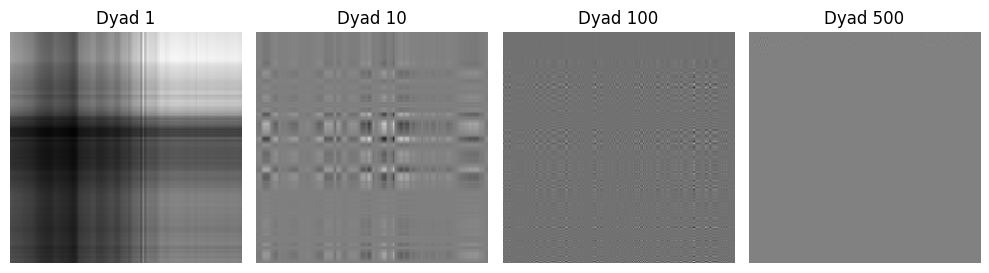

In [52]:
selected_singular_values = [1, 10, 100, 500] # the dyads we'll plot

plt.figure(figsize=(10,5))
for i, sigma_idx in enumerate(selected_singular_values, 1):
    # Reconstruct dyad
    dyad_reconstructed = np.outer(U[:, sigma_idx - 1] * S[sigma_idx - 1], Vt[sigma_idx - 1, :])

    # Plot
    plt.subplot(1, len(selected_singular_values), i)
    plt.imshow(dyad_reconstructed, cmap='gray')
    plt.title(f'Dyad {sigma_idx}')
    plt.axis('off')

plt.tight_layout()
plt.show()

**We can notice that the bigger the index of the dyad, the less detailed is the image.**

### 1.3) Plot the singular values of X. Do you note something?

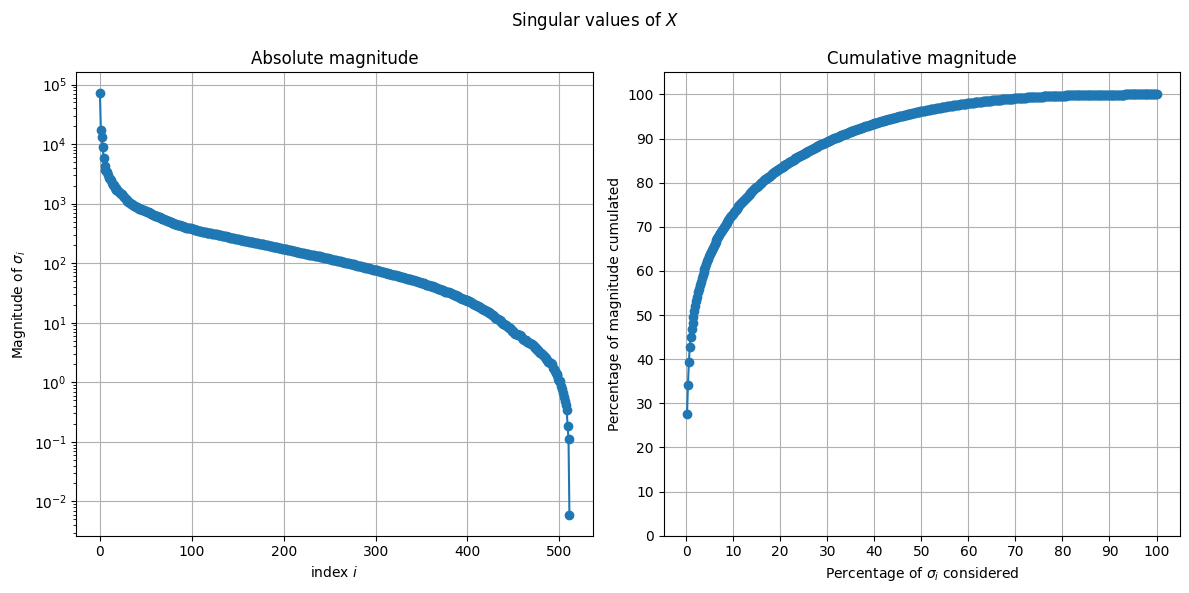

In [53]:
tot_info = sum(S)
cumulative_info = np.cumsum(S)
percent_info = cumulative_info / tot_info * 100
percent_dyads = np.arange(1, len(S) + 1) / len(S) * 100

fig, axes = plt.subplots(1,2, figsize=(12,6))
fig.suptitle(r"Singular values of $X$")

axes[0].plot(S, marker='o', label='Singular Values')
axes[0].set_title("Absolute magnitude")
axes[0].set_ylabel(r'Magnitude of $\sigma_i$')
axes[0].set_xlabel(r'index $i$')
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].plot(percent_dyads, percent_info, marker='o', label='Cumulative Information')
axes[1].set_title('Cumulative magnitude')
axes[1].set_ylabel(r'Percentage of magnitude cumulated')
axes[1].set_xlabel(r'Percentage of $\sigma_i$ considered')
axes[1].set_ylim(0,105)
axes[1].set_yticks(range(0, 101, 10))
axes[1].set_xticks(range(0, 101, 10))
axes[1].grid(True)

plt.tight_layout()
plt.show()

1. We can observe that the slope of the first plot is constantly descending, so that means that a point will always be more relevant than the next one.

2. We can observe that the slope of the first plot decreases at different rates. At the extrema the decrease is very quick and we loose 2 orders of magnitude in few dyads in both extrema, while in the middle the slope is more flatten and we loose 4 orders of magnitude with 90% of the dyads.

3. In the second plot we can clearly observe that most of the information is in the first dyads as it is clear that 90% of the information can be obtained with 30% of the dyads.

### 1.4) Visualize the $k$-rank approximation of X for different values of $k$. What do you observe?

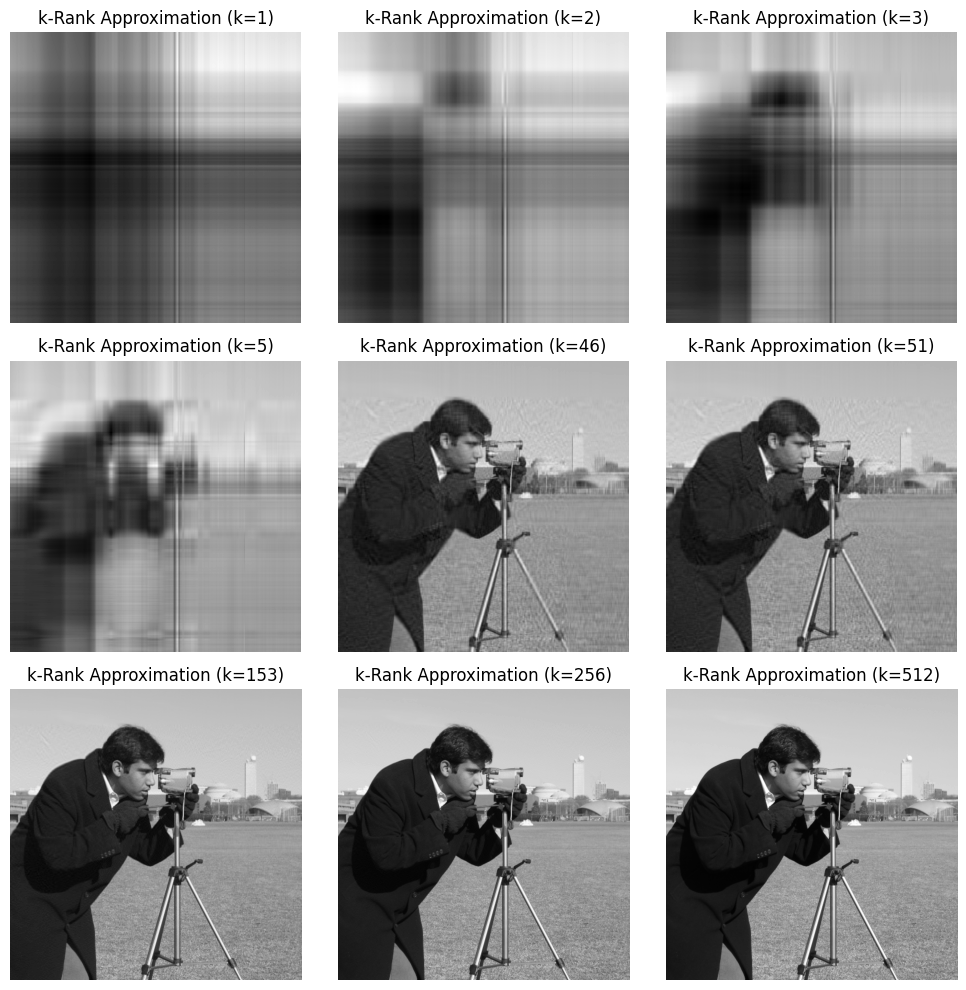

In [54]:
# From above we found out some notable indexes:

# - 1st dyad     (k=1)   -> 30% of info
# - 2nd dyad     (k=2)   -> 35% of info
# - 3rd dyad     (k=3)   -> 40% of info
# - 8% of dyads  (k=46)  -> 50% of info
# - 10% of dyads (k=51)  -> 75% of info
# - 30% of dyads (k=153) -> 90% of info
# - 50% of dyads (k=256) -> 95% of info

k_values = [1, 2, 3, 5, 46, 51, 153, 256, 512]

# Visualize k-rank approximations
plt.figure(figsize=(10, 10))

for i, k in enumerate(k_values, 1):
    # k-rank approximation
    X_approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

    # Plot
    plt.subplot(3, 3, i)
    plt.imshow(X_approx, cmap='gray')
    plt.title(f'k-Rank Approximation (k={k})')
    plt.axis('off')

plt.tight_layout()
plt.show()

As we expected before, after very few dyads is possible to see something and with 50 of them the image is quite clear. It is also hard to see differences between $k=153$ and $k=512$ .

### 1.5) Compute and plot the approximation error $||X-X_k||_F$ for increasing values of $k$, where $X_k$ is the $k$-rank approximation of $k$.

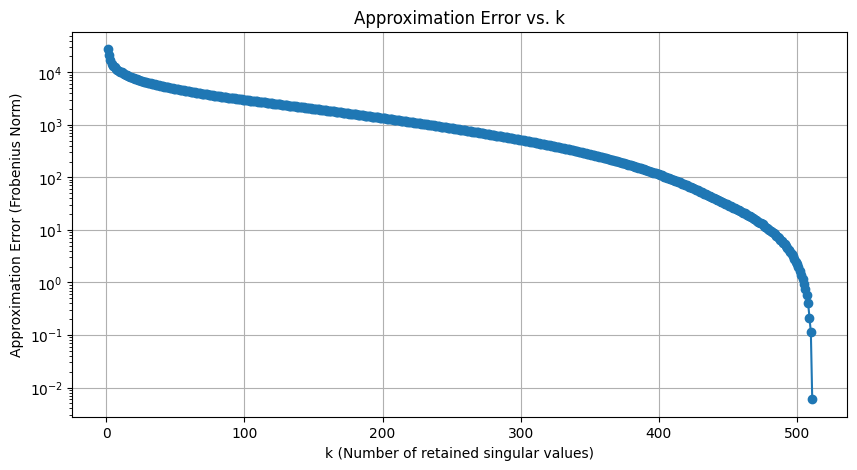

In [55]:
# Values of k (number of retained singular values)
k_values = np.arange(1, min(X.shape))

# Compute and plot approximation errors
approximation_errors = []

for k in k_values:
    # k-rank approximation
    Xk = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

    # Frobenius norm of the difference
    error = np.linalg.norm(X - Xk, 'fro')
    approximation_errors.append(error)

# Plot the approximation errors
plt.figure(figsize=(10,5))
plt.plot(k_values, approximation_errors, marker='o')
plt.title('Approximation Error vs. k')
plt.xlabel('k (Number of retained singular values)')
plt.ylabel('Approximation Error (Frobenius Norm)')
plt.yscale("log")
plt.grid(True)
plt.show()

As we can see, $k$ by $k$, we are taking the matrix $M$ that minimizes the distance from the original matrix $X$, solving:
$$\substack{\textbf{min} \\ {M:rk(M) = k}} \| M - X \|_F$$


### 1.6) Plot the compression factor $c_k = 1 −\frac{k(m+n+1)}{mn}$ for increasing $k$. 
What is the approximation error when the compressed image requires the same amount of information of those of the uncompressed image (i.e. $c_k = 0$)? 

We have c_k≈0 with k=255 (c_k = -0.0009765625)
The approximation error with k=255 is 818.441722


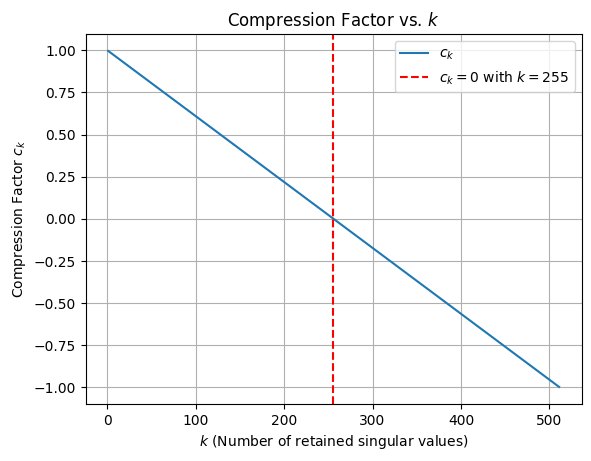

In [63]:
# Values of k (number of retained singular values)
k_values = np.arange(1, min(X.shape), 1)

# Compute compression factor ck
compression_factors = [1 - k * (m + n + 1) / (m * n) for k in k_values]

# Find k where ck = 0
k_zero_compression = np.argmin([v**2 for v in compression_factors])
print(fr'We have c_k≈0 with k={k_zero_compression} (c_k = {compression_factors[k_zero_compression]})')

# Find the approximation error when c_k = 0
k = k_zero_compression
X_approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
error = np.linalg.norm(X - X_approx, 'fro')
print(f"The approximation error with k={k_zero_compression} is {error:4f}")

# Plot compression factors
plt.plot(k_values, compression_factors, label=r'$c_k$')
plt.axvline(x=k_zero_compression, color='r', linestyle='--', label=rf'$c_k=0$ with $k={k_zero_compression}$')
plt.title(r'Compression Factor vs. $k$')
plt.xlabel(r'$k$ (Number of retained singular values)')
plt.ylabel(r'Compression Factor $c_k$')
plt.legend()
plt.grid(True)
plt.show()

There is still an error even with the $k$ that best compress the image since we use the same amount of data not the same data.

## 2) Classification of MNIST Digits with SVD Decomposition.

### 2.1) Load the MNIST dataset contained in `./data/MNIST.mat` with the function `scipy.io.loadmat()`. This dataset, which is loaded in the form of a matrix $X$, contains the flattened version of grayscale handwritten digits. Moreover, from the same file it is possible to load a vector I of length such that the $i$-th element of I is the true digit represented by the $i$-th image of $X$.

In [18]:
import pandas as pd
import numpy as np
dataset = pd.read_csv('./data.csv') 

data = np.array(dataset) # conversion from array to ndarray

# data = label | [...features...]
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels    

print(X.shape, Y.shape)

(784, 42000) (42000,)


### 2.2) Visualize a bunch of datapoints of $X$ with the function `plt.imshow()`.

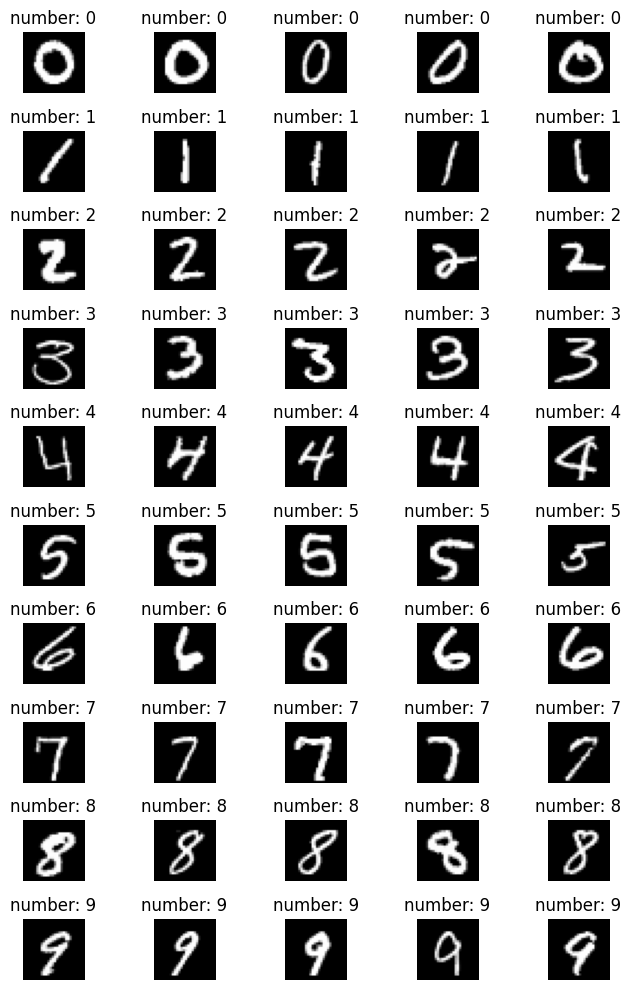

In [19]:
count = 1
plt.figure(figsize=(7,10))
for digit in range(0, 10):
    idxs = np.where(Y == digit)[0][:5] # i take the first 5 images of digit
    for idx in idxs :
        plt.subplot(10, 5, count)
        image = X[:,idx]
        image = np.reshape(image, (28, 28))
        plt.imshow(image, cmap='gray')
        plt.title(f"number: {digit}")
        plt.axis('off')
        count += 1
plt.tight_layout()
plt.show()

### 2.3) Extract from $X$ those columns that corresponds to digits 3 or 4. Those digits represents the classes $C_1$ and $C_2$ defined above.

In [20]:
idxs = np.where((Y == 3) | (Y == 4))[0]
X = X[:, idxs]
Y = Y[idxs]

### 2.4) Split the obtained dataset in training and testing. 
**From now on, we will only consider the training set.**

The test set will be only used at the end of the exercise to test the algorithm.

In [30]:
def train_test_split (X, Y, N, perc) :
    idx = np.arange(0, N)
    np.random.shuffle(idx)

    idx_train = int(perc*N)

    train_idx = idx[:idx_train]
    test_idx = idx[idx_train:]

    X_train = X[:, train_idx]
    Y_train = Y[train_idx]

    X_test = X[:, test_idx]
    Y_test = Y[test_idx]
    return X_train, X_test, Y_train, Y_test


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, X.shape[1], 0.80)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(784, 6738) (784, 1685)
(6738,) (1685,)


### 2.5) Create the matrices $X_1$ and $X_2$ defined above from $X$

In [31]:
# They are already flatten
X1 = X_train[:, (Y_train == 3)]
X2 = X_train[:, (Y_train == 4)]
print(X1.shape, X2.shape)

(784, 3503) (784, 3235)


### 1.6) Compute the SVD decomposition of $X_1$ and $X_2$ with `np.linalg.svd(matrix, full matrices=False)` and denote the U-part of the two decompositions as $U_1$ and $U_2$

In [32]:
U1, s1, VT1 = np.linalg.svd(X1, full_matrices = False)
U2, s2, VT2 = np.linalg.svd(X2, full_matrices = False)

# Test
print(np.linalg.matrix_rank(X1), min(X1.shape))
print(np.linalg.matrix_rank(X2), min(X2.shape))

540 784
558 784


NOTE: here is useful using `full_matrices = False` since the matrices are not full-rank.

### 2.7) Take an unknown digit y from the test set, and compute $y_1^⊥ = U_1(U^T_1 y)$ and $y_2^⊥ = U_2(U^T_2 y)$

In [33]:
# random_index = np.random.randint(0, Y.shape[0])
random_index = 41 # for debug purpose

# Extract unknown digit
random_digit = Y_test[random_index]
y = X_test[:, random_index]

# Compute
y1 = U1 @ (U1.T @ y)
y2 = U2 @ (U2.T @ y)

### 2.8) Compute the distances $d1 = ||y −y^⊥_1 ||_2$ and $d2 = ||y −y^⊥_2 ||_2$ and classify $y$ to $C_1$ if $d_1 < d_2$ and to $C_2$ if $d_2 < d_1$

y is C1 (number 3)


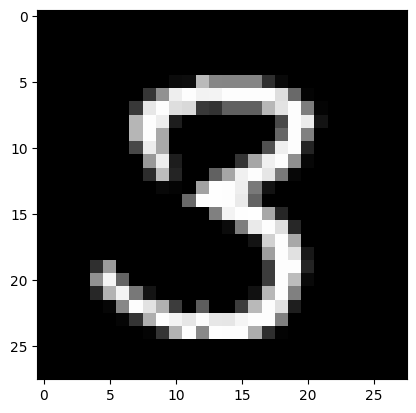

In [34]:
d1 = np.linalg.norm(y-y1, 2)
d2 = np.linalg.norm(y-y2, 2)

# Output
if d1 < d2 : print("y is C1 (number 3)")
else : print("y is C2 (number 4)")
plt.imshow(np.reshape(y, (28,28)),cmap='grey'); # to check visually the prediction
plt.show()

### 2.9) Repeat the experiment for different values of $y$ in the test set. Compute the misclassification number for this algorithm

In [37]:
def experiment(U1, U2, X, Y, C1, C2) :
    misclassifications = 0
    for i in range(Y.shape[0]) :
        y = X[:, i]
        # plt.imshow(np.reshape(y, (28,28)),cmap='grey')
        y1 = U1 @ (U1.T @ y)
        y2 = U2 @ (U2.T @ y)
        d1 = np.linalg.norm(y - y1, 2)
        d2 = np.linalg.norm(y - y2, 2)
        if (d1 < d2) & (Y[i] == C2):
            misclassifications += 1
        elif (d1 > d2) & (Y[i] == C1):
            misclassifications += 1
            
    return misclassifications/Y.shape[0] * 100.0

In [38]:
# Compute misclassification for train set
mis_train = experiment(U1, U2, X_train, Y_train, 3, 4)
print(f"The missclassification for train set is {mis_train}%")

# Compute misclassification for test set
mis_test = experiment(U1, U2, X_test, Y_test, 3, 4)
print(f"The missclassification for test set is {mis_test}%")

The missclassification for train set is 4.541406945681211%
The missclassification for test set is 5.163204747774481%


I noticed that there is also a strange behaviour about the misclassification with respect to the `train_size` (as can be seen in `experiment_train_size.ipynb`).

The overall of the experiment with different train sizes has shown that the behaviour is quite normal all around the gaph with a general low misclassification both in train and test with some exceptions which appear to me more oultliers non related to the train_size. A closer look to the first values showed a singolar pattern as both misclassifications were low but with very low train_size. 

### 2.10) Repeat the experiment for different digits other than 3 or 4. There is a relationship between the visual similarity of the digits and the classification error?

In [24]:
def generalized_digits_experiment(n1, n2, train_size, X, Y) :
    idx = (Y == n1) | (Y == n2)
    X = X[:, idx]
    Y = Y[idx]
    
    d, N = X.shape
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, N, train_size)
    
    idx = (Y_train == n1)
    X1 = X_train[:, idx]
    idx = (Y_train == n2)
    X2 = X_train[:, idx]

    U1, s1, VT1 = np.linalg.svd(X1, full_matrices = False)
    U2, s2, VT2 = np.linalg.svd(X2, full_matrices = False)

    mis_number = experiment(U1, U2, X_test, Y_test, n1, n2)
    return mis_number

Average misclassification along the experiment: 8.98%


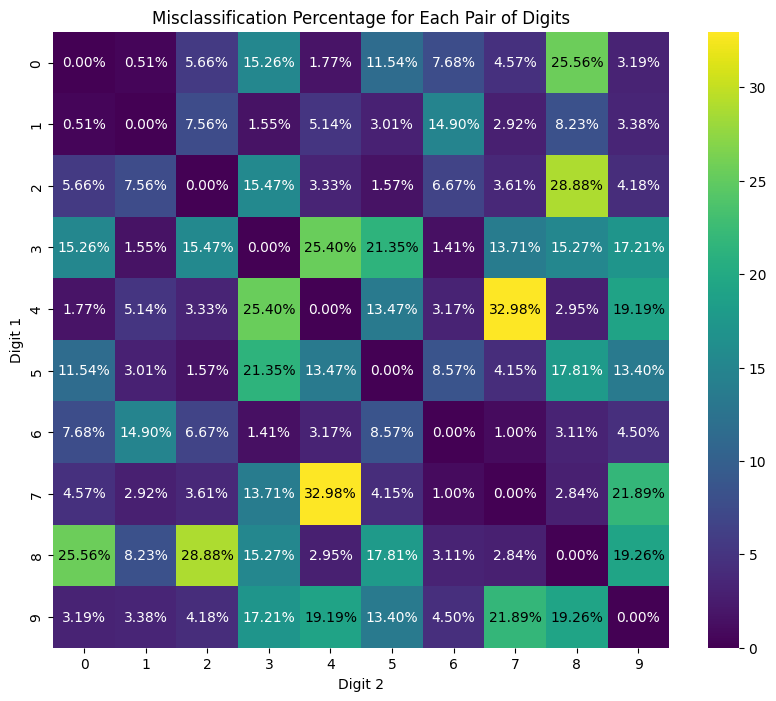

In [25]:
# Reload the dataset
dataset = pd.read_csv('./data.csv') 
data = np.array(dataset) # conversion from array to ndarray
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels  

misclassification_matrix = np.zeros((10, 10))

# Symmetrical to make the experiment quickier
for digit1 in range(10) :
    for digit2 in range(digit1, 10) :
        if digit1 != digit2:
            mis_test_d1_d2 = generalized_digits_experiment(digit1, digit2, 0.80, X, Y)
            misclassification_matrix[digit1, digit2] = mis_test_d1_d2
            misclassification_matrix[digit2, digit1] = mis_test_d1_d2


print(f"Average misclassification along the experiment: {np.mean(misclassification_matrix):.2f}%")
plt.figure(figsize=(10, 8))
sns.heatmap(misclassification_matrix, fmt=".2f", cmap="viridis", annot=False, square=True, cbar=True)
plt.xlabel('Digit 2')
plt.ylabel('Digit 1')
plt.title('Misclassification Percentage for Each Pair of Digits')

# Since the sns.heatmap isn't able to print percentages 
# on the heatmap cells from the first and down
for i in range(misclassification_matrix.shape[0]):
    for j in range(misclassification_matrix.shape[1]):
        plt.text(j + 0.5, i + 0.5, f"{misclassification_matrix[i, j]:.2f}%", 
                 ha='center', va='center', 
                 color="white" if misclassification_matrix[i, j]<2*np.mean(misclassification_matrix) else "black")

plt.show()

### 2.11) Comment the obtained results.

In many runs i obtained much different results so that i couldn't conclude a relation among the misclassfication and the digit (and its features)

### 2.12) Repeat the exercise above with a 3-digit example. Comment the differences.

In [77]:
def classify(U:dict, X, Y) :
    misclassifications = 0
    
    for i in range(Y.shape[0]) :
        y = X[:, i]

        # I have to consider the distances from y to all the possible classes
        distances = {} 

        # Compute the distances
        for n in U.keys():
            U_k = U[n]
            y_k = U_k @ (U_k.T @ y)
            distances[n] = np.linalg.norm(y - y_k)
        predicted = min(distances, key=distances.get)

        # Verify result
        if predicted != Y[i] : misclassifications += 1

    return misclassifications/Y.shape[0] * 100.0

def generalized_experiment(numbers, train_size, X, Y) :
    idx = np.isin(Y, numbers)
    X = X[:, idx]
    Y = Y[idx]
    d, N = X.shape
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, N, train_size)

    U = {}
    for n in numbers:
        idx = (Y_train == n)
        X_k = X_train[:, idx]
        U_k, sk, VTk = np.linalg.svd(X_k, full_matrices = False)
        U[n] = U_k
    
    return classify(U, X_test, Y_test)

In [27]:
# Reload the dataset
dataset = pd.read_csv('./data.csv') 
data = np.array(dataset) # conversion from array to ndarray
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels  

ks = {k+1:list(range(0,k+1)) for k in range(1,10)}
misclassifications = []
for k, digits in tqdm(ks.items(), desc="Processing ks"):
    misclassifications.append(generalized_experiment(digits, 0.80, X, Y))

Processing ks: 100%|██████████| 9/9 [03:59<00:00, 26.63s/it]


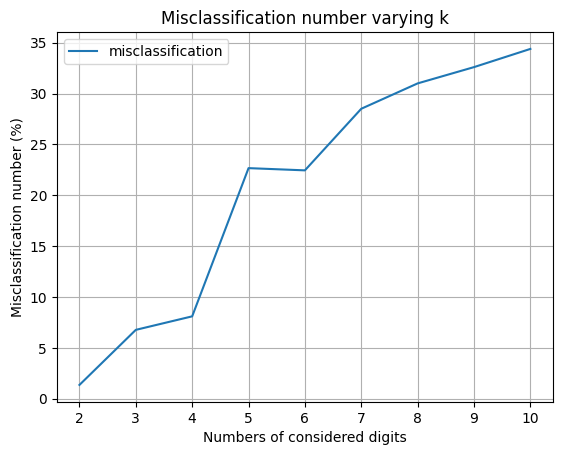

In [28]:
plt.title('Misclassification number varying k')
plt.xlabel('Numbers of considered digits')
plt.ylabel('Misclassification number (%)')
plt.grid()
plt.plot(list(ks.keys()), misclassifications, label="misclassification")
plt.legend()
plt.show()

As we would expect the misclassification grows as we consider more digits.

In [79]:
# Try the same experiment as before but with digits in different order 
# and as a consequence different subsets

# Reload the dataset
dataset = pd.read_csv('./data.csv') 
data = np.array(dataset) # conversion from array to ndarray
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels  

#  Choose how many experiments
num_digits = 10
num_permutations = 5

digits = range(0, 10)
all_perms = list(permutations(digits, num_digits)) 

# 3_628_800 combinations, we have to prune :(
random_permutations = random.sample(all_perms, num_permutations)
i = 0
misclassifications = {perm : [] for perm in random_permutations}
for perm in random_permutations :
    print(f"Combination {i} : {perm}") # for readibility
    ks = {k + 1: perm[:k + 1] for k in range(1, 10)}
    
    for k, digits in ks.items():
        misclassifications[perm].append(generalized_experiment(digits, 0.75, X, Y))    
    i += 1

Combination 0 : (2, 0, 7, 9, 6, 3, 8, 5, 4, 1)
Combination 1 : (8, 1, 7, 3, 9, 6, 5, 0, 2, 4)
Combination 2 : (4, 1, 3, 8, 0, 9, 2, 7, 6, 5)
Combination 3 : (1, 6, 9, 7, 0, 2, 8, 3, 4, 5)
Combination 4 : (3, 4, 2, 7, 9, 0, 1, 5, 8, 6)


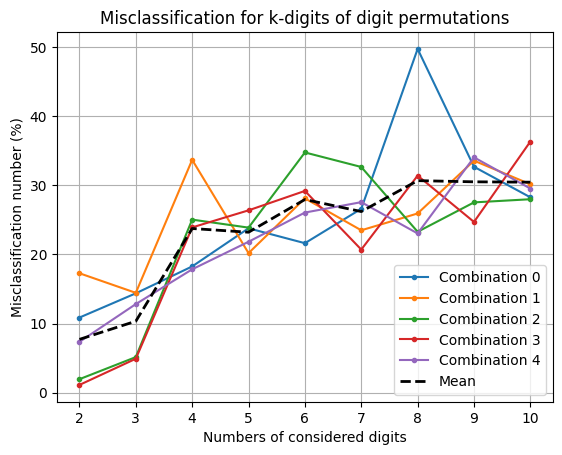

In [81]:
means = [np.mean([misclassifications[perm][i - 2] for perm in random_permutations]) for i in range(2, 11)]

for i, perm in enumerate(random_permutations):
    plt.plot(list(range(2, 11)), misclassifications[perm], '.-', label=f'Combination {i}')
plt.plot(list(range(2, 11)), means, 'k--', linewidth=2, label='Mean')

plt.title('Misclassification for k-digits of digit permutations')
plt.xlabel('Numbers of considered digits')
plt.ylabel('Misclassification number (%)')
plt.legend()
plt.grid()
plt.show()

As we expected, there are some changes with respect to the order of the digits but the average result isn't that different as the one obtained before.

## 3) Clustering with PCA

### 3.1) Load the dataset in memory and explore its head and shape to understand how the informations are placed inside of it

In [92]:
import pandas as pd
import numpy as np
dataset = pd.read_csv('./data.csv') 
display(dataset.head())
display(dataset.shape)
np.random.seed(42)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(42000, 785)

### 3.2) Split the dataset into the $X$ matrix of dimension $d \times N$, with $d = 784$ being the dimension of each datum, $N$ is the number of datapoints, and $Y \in \mathbb{R}^N$ containing the corresponding labels

In [93]:
data = np.array(dataset) # conversion from array to ndarray

# data = label | [...features...]
X = data[:, 1:].T   # extract features  
Y = data[:, 0]      # extract labels    

print(X.shape, Y.shape)

(784, 42000) (42000,)


### 3.3) Choose a number of digits (for example, 0, 6 and 9) and extract from $X$ and $Y$ the sub-dataset containing only the considered digits. Re-call $X$ and $Y$ those datasets, since the originals are not required anymore

In [94]:
digits = [0, 6, 9]
idx = np.isin(Y,digits)

Y = Y[idx]
X = X[:, idx]

d, N = X.shape

print(X.shape, Y.shape)

(784, 12457) (12457,)


### 3.4) Set $N_{train} < N$ and randomly sample a training set with $N_{train}$ datapoints from $X$ (and the corresponding $Y$ ). Call them $X_{train}$ and $Y_{train}$. Everything else is the test set. Call it $X_{test}$ and $Y_{test}$.

In [95]:
def train_test_split (X, Y, N, train_perc) :
    N_train = int(X.shape[1]*train_perc)
    
    idx = np.arange(0, N)
    np.random.shuffle(idx)

    train_idx = idx[:N_train]
    test_idx = idx[N_train:]

    X_train = X[:, train_idx]
    Y_train = Y[train_idx]

    X_test = X[:, test_idx]
    Y_test = Y[test_idx]
    return X_train, X_test, Y_train, Y_test

In [96]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, N, 0.75)
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(784, 9342) (784, 3115)
(9342,) (3115,)


### 3.5) Implement the algorithms computing the PCA of $X_{train}$ with a fixed $k$. Visualize the results (for $k = 2$) and the position of the centroid of each cluster

In [97]:
def centroid(X):
    return np.mean(X, axis=1, keepdims=True)

In [98]:
# Centroid of the dataset
cX = centroid(X_train)
print(cX.shape)

# Centered dataset
Xc = X_train - cX

# SVD of Xc
U, s, VT = np.linalg.svd(Xc, full_matrices=False)

# Truncated SVD of Xc
k = 2
U_k = U[:, :k]

# Projected dataset
U_k = - U_k   # we want positive scores 
Z_k  = U_k.T @ Xc
print(U_k.T.shape, Xc.shape, Z_k.shape)

(784, 1)
(2, 784) (784, 9342) (2, 9342)


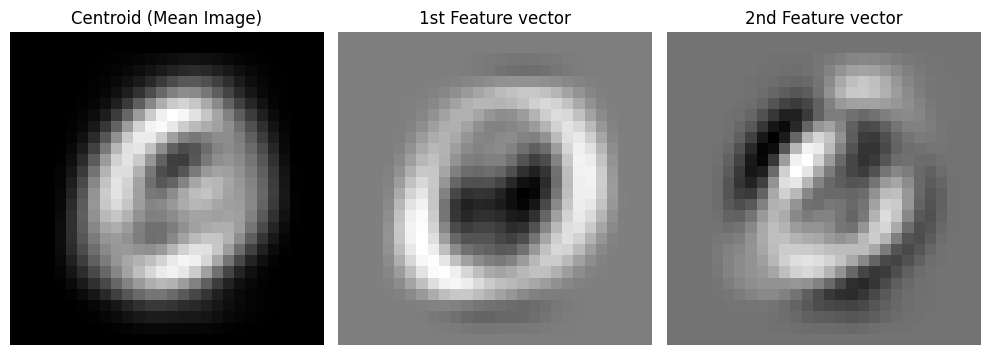

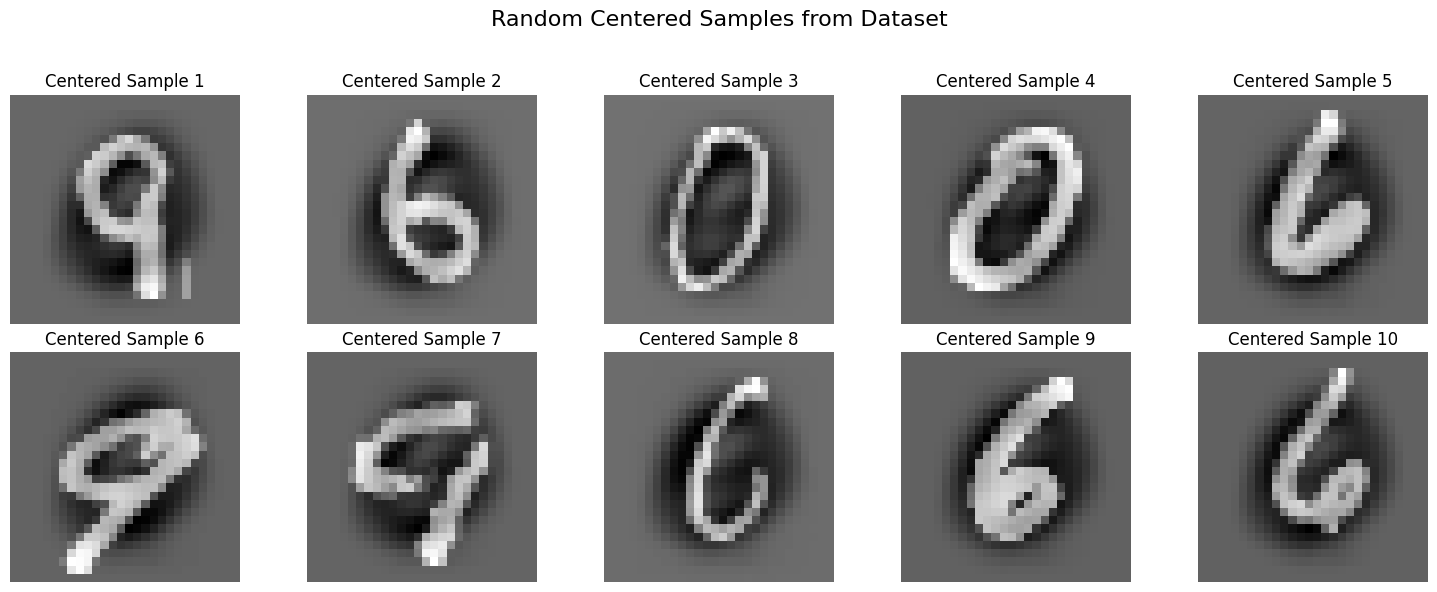

In [99]:
import random
fig = plt.figure(figsize=(10, 15))

# Centroid
ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(np.reshape(cX, (28, 28)), cmap='grey')
ax1.set_title("Centroid (Mean Image)")
ax1.axis('off')

# 1st Principal Component
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(np.reshape(U_k.T[0], (28, 28)), cmap='grey')
ax2.set_title("1st Feature vector")
ax2.axis('off')

# 2nd Principal Component
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(np.reshape(U_k.T[1], (28, 28)), cmap='grey')
ax3.set_title("2nd Feature vector")
ax3.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i < 10:
        random_idx = random.randint(0, Xc.shape[1] - 1)
        ax.imshow(np.reshape(Xc.T[random_idx], (28, 28)), cmap='grey')
        ax.set_title(f"Centered Sample {i+1}")
        ax.axis('off')
    else:
        ax.axis('off')

fig.suptitle("Random Centered Samples from Dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout for the global title
plt.show()


We can make some observations on the visualization of these structures:

1. **Centroid**
    - It is the average image in the dataset and indeed we can clearly see 0, 6 and 9 stuck toghether.

2. **Principal components**
    - The $1^{st}$ helps in differentiating 0 from 6 and 9.
    - The $2^{nd}$ shows the 6 structure which helps in differentiating among 6 and 9.

3. **Random samples from centered dataset**
    - They show how the digit differentiate from the cluster in proportions, thickness and structure.

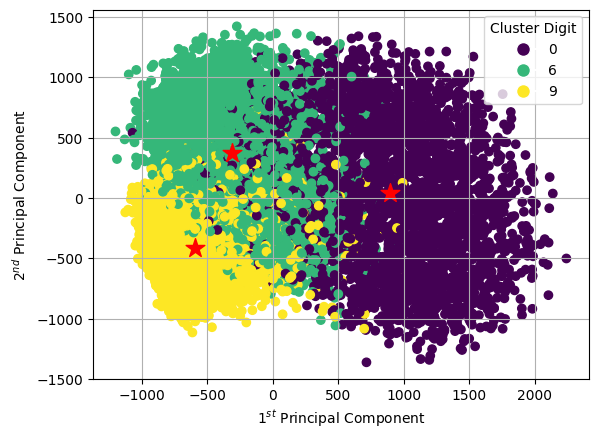

In [100]:
from matplotlib.lines import Line2D

# Visualize clusters
scatter = plt.scatter(Z_k[0, :], Z_k[1, :], c=Y_train, cmap='viridis')

for i in digits:
    idx = (Y_train == i)
    cluster_i = Z_k[:, idx]
    C_digit = centroid(cluster_i)
    plt.scatter(C_digit[0, 0], C_digit[1, 0], marker="*", s=200, c='red')

# Create the legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label=str(digit),
                          markerfacecolor=scatter.cmap(scatter.norm(digit)), markersize=10)
                   for digit in digits]
plt.legend(handles=legend_elements, title="Cluster Digit")

plt.xlabel(r"$1^{st}$ Principal Component")
plt.ylabel(r"$2^{nd}$ Principal Component")
plt.grid()
plt.show()

As expected before, the clusters are quite well divided:
- If the image matches the PC1 (negative value), then it's a 0, independently from the PC2.
- If the image doesn't match PC1 (positive value), then it's a 6 or 9, then if matches PC2 (negative value) it will be a 6 otherwise it will be a 9.

NB: scores are negative/positive if image matches and viceversa since the Principal compoenents present the patterns as negative/positive values. By repeating the experiment with `U_k = -U_k` the scores will be opposite.

### 3.6) Compute, for each cluster, the average distance from the centroid. Comment the result

In [208]:
# Compute centroids for each cluster
centroids = {}
for i in digits:
    idx = (Y_train == i)
    cluster_i = Z_k[:, idx]
    centroids[i] = centroid(cluster_i)

In [209]:
# For each cluster, average distance from the centroid
for digit in centroids.keys() :
    cluster_i = Z_k[:, (Y_train == digit)]
    avg_distance = 0
    m = cluster_i.shape[1]
    for k in range(0, m):
        avg_distance += np.linalg.norm(cluster_i[:,k].flatten() - centroids[digit].flatten())
    avg_distance /= m
    print(f"Average distance from the centroid for cluster {digit} : {'%.2f' % avg_distance}")

Average distance from the centroid for cluster 0 : 745.53
Average distance from the centroid for cluster 6 : 548.80
Average distance from the centroid for cluster 9 : 372.88


### 3.7) Compute, for each cluster, the average distance from the centroid on the test set. Comment the results

In [210]:
# Centroid of the dataset
cX = centroid(X_test)

# Centered dataset
Xc = X_test - cX

# Projected dataset
# • U_k is from the train set
Z_k  = U_k.T @ Xc

# Compute centroids for each cluster
centroids = {}
for i in digits:
    idx = (Y_test == i)
    cluster_i = Z_k[:, idx]
    centroids[i] = centroid(cluster_i)

# For each cluster, average distance from the centroid
for digit in centroids.keys() :
    cluster_i = Z_k[:, (Y_test == digit)]
    avg_distance = 0
    m = cluster_i.shape[1]
    for k in range(0, m):
        avg_distance += np.linalg.norm(cluster_i[:,k].flatten() - centroids[digit].flatten())
    avg_distance /= m
    print(f"Average distance from the centroid for cluster {digit} : {'%.2f' % avg_distance}")

Average distance from the centroid for cluster 0 : 748.05
Average distance from the centroid for cluster 6 : 542.19
Average distance from the centroid for cluster 9 : 371.17


**The average distance is the same as in the train set**

### 3.8) Define a classification algorithm in this way: given a new observation $x$, compute the distance between $x$ and each cluster centroid. Assign $x$ to the class corresponding the the closer centroid. Compute the accuracy of this algorithm on the test set and compute its accuracy

In [211]:
def classify(x, centroids):
    distances = {}
    for n in centroids.keys():
        x=np.reshape(x, (x.shape[0],1))
        distances[n] = np.linalg.norm(x.flatten() - centroids[n].flatten())
    return min(distances, key=distances.get) 

In [212]:
XC = centroid(X_train)
X_test_c = X_test - XC
Z_test = U_k.T @ X_test_c
mis_number = 0
while i < X_test.shape[1]:
    if classify(Z_test[:, i], centroids) != Y_test[i]:
        mis_number += 1
    i +=1
print(f"Misclassification number: {mis_number / X_test.shape[1] * 100:.4f}%")

Misclassification number: 16.5008%


### 3.9) Repeat this experiment for different values of $k$ and different digits. What do you observe?

In [213]:
# Different digits
D = ([0, 6, 9], [3, 8, 9], [0, 4, 7], [5, 6, 9], [1, 2, 4], [7, 5, 3])

# Different k
K = [2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 100, 150]

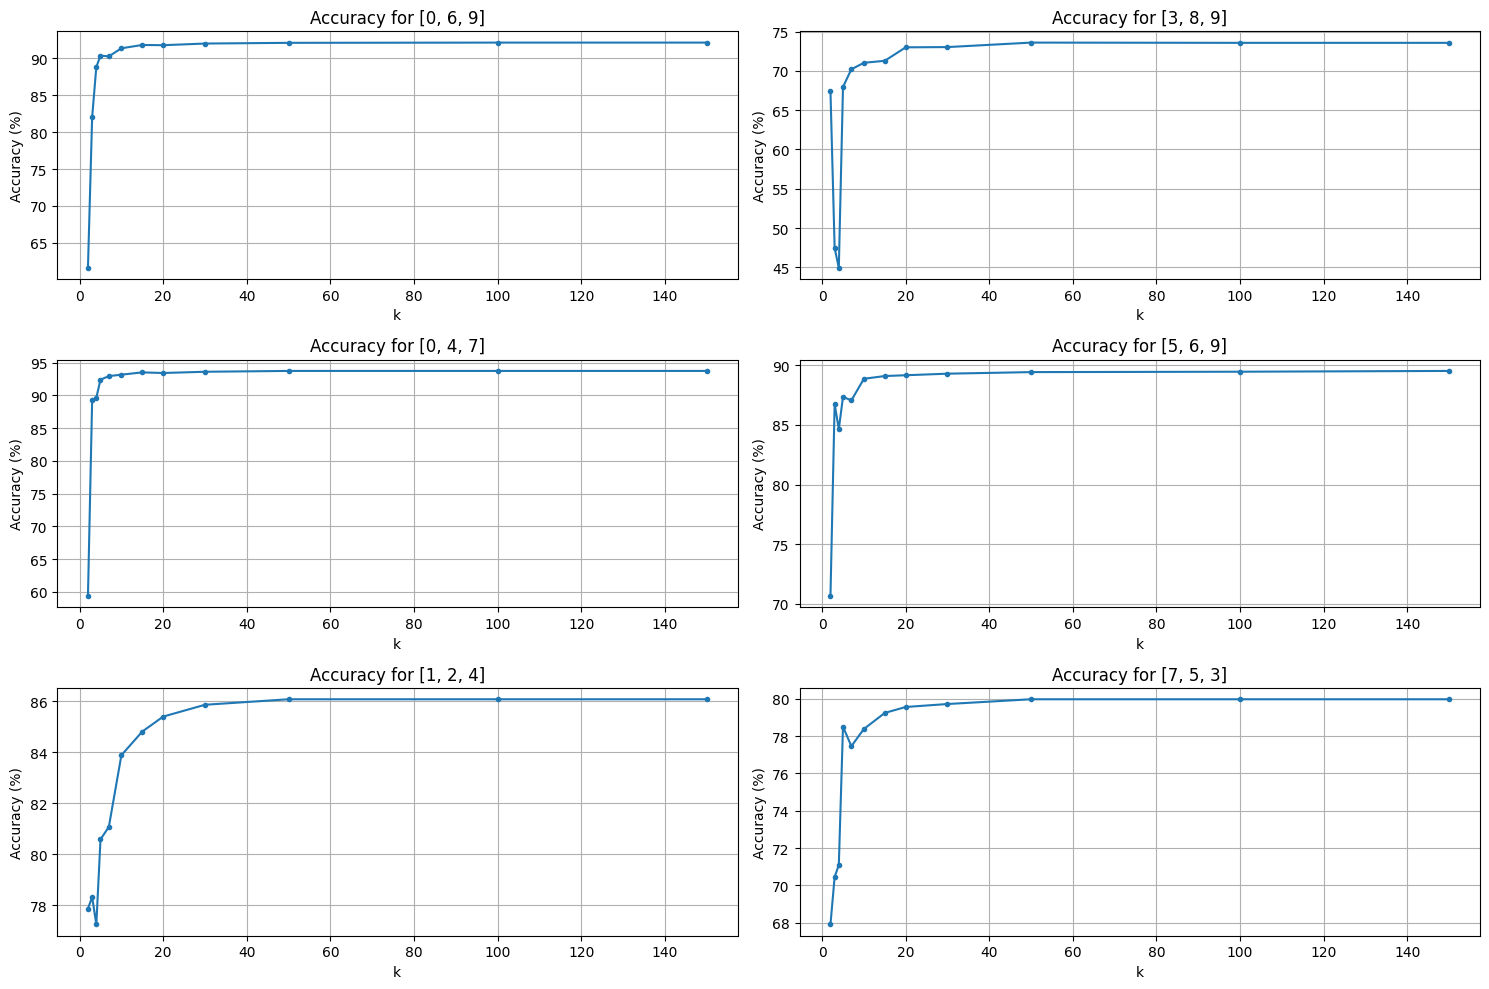

In [215]:
from math import ceil, sqrt

# Load dataset
dataset = pd.read_csv('./data.csv')
dataset = np.array(dataset)

# Square grid
n_plots = len(D)
rows = int(ceil(sqrt(n_plots)))  
cols = int(ceil(n_plots / rows))  

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()  

for digits_idx, digits in enumerate(D):
    # Split data and labels
    X = dataset[:, 1:].T
    Y = dataset[:, 0].T

    # Reduce the dataset
    idx = np.isin(Y, digits)
    Y = Y[idx]
    X = X[:, idx]
    d, N = X.shape

    # Split train and test
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, N, 0.75)

    # Centroid of the dataset
    cX = centroid(X_train)

    # Centered dataset
    Xc = X_train - cX

    # SVD of Xc
    U, s, VT = np.linalg.svd(Xc, full_matrices=False)

    mis_numbers = []
    for k in K:
        # Truncated SVD of Xc
        U_k = U[:, :k]

        # Projected dataset
        Z_k = U_k.T @ Xc

        # Centroids computing
        centroids = {}
        for i in digits:
            idx_t = (Y_train == i)
            cluster_i = Z_k[:, idx_t]
            centroids[i] = centroid(cluster_i)

        # Projection of test set
        Z_test = U_k.T @ X_test
        mis_number = 0

        # Classification of test set
        for i in range(X_test.shape[1]):
            if classify(Z_test[:, i], centroids) != Y_test[i]:
                mis_number += 1
        mis_numbers.append(mis_number / X_test.shape[1])

    # Plot misclassification varying k
    accuracy = [(1 - num) * 100 for num in mis_numbers]
    ax = axes[digits_idx]
    ax.plot(K, accuracy, '.-')
    ax.set_title(f'Accuracy for {digits}')
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('k')
    ax.grid()

# Remove empty plots
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

**We can notice that the more we reduce dimensions and the better we missclassificate but it's not linear, after $k=20/30$ all the missclassfication are next to their minimum. Since we started with more that 700 dimensions, that would mean a reduction of 95% of the dimensions.**

### 3.10) Compare this classification algorithm with the one defined in the previous exercise. Which performs better?

In [216]:
# Have to redefine the functions as they got overwritten in PCA section

def classify(U:dict, X, Y) :
    misclassifications = 0
    
    for i in range(Y.shape[0]) :
        y = X[:, i]

        # I have to consider the distances from y to all the possible classes
        distances = {} 

        # Compute the distances
        for n in U.keys():
            U_k = U[n]
            y_k = U_k @ (U_k.T @ y)
            distances[n] = np.linalg.norm(y - y_k)
        predicted = min(distances, key=distances.get)

        # Verify result
        if predicted != Y[i] : misclassifications += 1

    return misclassifications/Y.shape[0] * 100.0

def generalized_experiment(numbers, train_size, X, Y) :
    idx = np.isin(Y, numbers)
    X = X[:, idx]
    Y = Y[idx]
    d, N = X.shape
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, N, train_size)

    U = {}
    for n in numbers:
        idx = (Y_train == n)
        X_k = X_train[:, idx]
        U_k, sk, VTk = np.linalg.svd(X_k, full_matrices = False)
        U[n] = U_k
    
    return classify(U, X_test, Y_test)

In [217]:
# Compare accuracy with the SVD classification
dataset = pd.read_csv('./data.csv')
dataset = np.array(dataset)
X = dataset[:, 1:].T
Y = dataset[:, 0].T

for digits_idx, digits in enumerate(D):
    print(f"Accuracy for {digits}: {100 - generalized_experiment(digits, 0.75, X, Y)}%")

Accuracy for [0, 6, 9]: 73.0016051364366%
Accuracy for [3, 8, 9]: 69.31132973659156%
Accuracy for [0, 4, 7]: 94.5748730964467%
Accuracy for [5, 6, 9]: 92.27722772277228%
Accuracy for [1, 2, 4]: 91.74397031539888%
Accuracy for [7, 5, 3]: 77.04813516098183%


There is not an algorithm clearly better than the other, as sometimes is better SVD classificationa and sometimes PCA.